# ICS 2405: Knowledge-Based Systmes

## comparing learners/models:
this is meant to deternine what sort of model to go with -selecting the best one out of the ones you have

### how it works:


>INFO: comparing models to come up with the best one out of multiple model architecures
>

#### model architectures
if you are comparing a 3-NN and 10-NN (k-NNs) and naive bayes models, there is errors and noise that affects how the models work and they are called bias and variance respectively.  

a 3-nn and a 10-nn model or a naive bayes are completely different archictectures. getting a comepletely useful k is not the correct thing to do and even if changing it gets me good learning system; that is not enough. in essence the proces should be done purely based on data.  

##### definitions and context:
`bias` - the limited capacity of a learning system to cover all bases - can be compared to the learning capacity of human cognition functions and memory/retention; i.e. we might miss out some info  
`variance`- comes from noisy dataset  

all this problems come from how much data we are dealing with and can be seen as depending on the quality of the dataset  


## why `less` is `more`:
a risk in developing a learning system is overestimating how well it will do when
we use it. to think that our model knows a lot is a problematic assumption.
getting more from less means we are utilizing well the dataset for training and testing and by extension eveluation(see below how this is done).

### again, we split the data:
we normally use the precipe below to divide the dataset:
- step one: split our data into separate training and testing datasets
- step two: learn on the training data.
- step three: evaluate on the testing data.


### questions:
wouldn’t building a model on more data lead to better results?” a humble skeptic asking this has a good point, ey? 

in general,  using more data should lead to better estimates by our learner. the learner should have better parameters.

regardless of whether or not we use all of the trainining data, a question we'd ask is this:  

> question:  
> how would we know that a more-data model is better than a less-data model?

## learning phases:
1. **assessment**: final, last-chance estimate of how the machine will do when operating in
the wild
2. **selection**: evaluating and comparing different machines which may represent the same
broad type of machine (different k in k-NN) or completely different machines
(k-NN and Naive Bayes)
3. **training**: setting knobs to their optimal values and providing auxiliary side-tray
information

## datasets:
the datasets used for these phases(above) are:
1. hold-out test set
2. validation test set
3. training set

we can relate these phases and datasets to the factory machine scenario(from analogy). so working from the inside out.
1. the **training set** is used to adjust the knobs on the factory machine.
2. the **validation test set** is used to get a non-taught-to-the-test evaluation of that
finely optimized machine and help us pick between different optimized machines.
3. the **hold-out test set** is used to make sure that the entire process of building one or more
factory machines, optimizing them, evaluating them, and picking among them is evaluated
fairly.

### parameters and hyperparameters
for a **k-NN**, different values of `k` are entirely different machines/models. `k` is not a parameter we adjust on the machine/model. `k` is internal to the machine/model - a hyprparameter.  

we could get a 3-NN, a 10-NN, and a naive bayes. to pick among them, we run our input-output pairs through
the models to train them.  

we evaluate how they perform on the held-out data to get a better—less trained on the test. we use our held-out data as the basis for picking the best machine.

NOTE: parameters are set as part of the learning method in the training phase while hyperparameters are beyond the control of the learning method. 

### overfitting and underfitting
what could go wrong with learning.  


the learning system either specializes to the data so much (may focus on the wrong detail/features - from noisy data even) such that it is not easy for it to understand context outside of the training dataset; this is a case of overfitting.  

the model learned not enough features from training - underfitting.  

either way, this is problematic.


In [1]:
# setup
from mlwpy import *
diabetes = datasets.load_diabetes()
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
from sklearn import model_selection as skms, linear_model, metrics

### synthetic data and linear regression
lets used controlled data with just one feature and uniform(distribution) noise.  


In [3]:
N = 20

ftr = np.linspace(-10, 10, num=N) # ftr values
tgt = 2*ftr**2 - 3 + np.random.uniform(-2, 2, N) # tgt = func(ftr)

(train_ftr, test_ftr, train_tgt, test_tgt) = skms.train_test_split(ftr, tgt, test_size=N//2)

display(pd.DataFrame({"ftr":train_ftr, "tgt":train_tgt}).T)

,0,1,2,3,4,5,6,7,8,9
ftr,-1.5789,-6.8421,-3.6842,1.5789,-7.8947,3.6842,7.8947,4.7368,5.7895,-0.5263
tgt,2.3906,91.0234,22.3791,3.8658,122.5817,22.9962,121.7528,40.6026,62.7696,-1.6137


### visualizing the synthetic data
we can take a look at that data visually. we have our known data points—the
training set—in blue dots. the red pluses show the input feature values for the test set. We
need to figure out how high up we should take each of those values

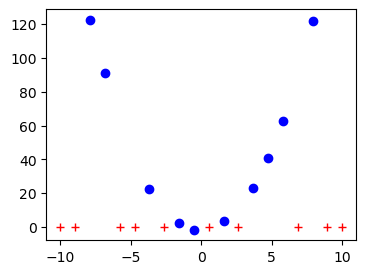

In [4]:
plt.plot(train_ftr, train_tgt, 'bo')
plt.plot(test_ftr, np.zeros_like(test_ftr), 'r+');

In [5]:
# note: sklearn *really* wants 2D inputs (a table)
# so we use rehape here.
sk_model = linear_model.LinearRegression()
sk_model.fit(train_ftr.reshape(-1, 1), train_tgt)
sk_preds = sk_model.predict(test_ftr.reshape(-1, 1))
sk_preds[:3]

array([53.218 , 41.4552, 56.8374])

#### `polyfit` routine in numpy: 
`polyfit` routine in numpy takes input and output values, our features and a target, and a degree of polynomial to align with the data. it allows us to set the hyperparameters of the model. it figures
out the right knob values—actually(coefficients of polynomials) and then `np.poly1d` turns those coefficients into a function that can take inputs and produce outputs. this is how it works:

In [6]:
# fit-predict-evaluate a 1D polynomial (a line)
model_one = np.poly1d(np.polyfit(train_ftr, train_tgt, 1))
preds_one = model_one(test_ftr)
print(preds_one[:3])

[53.218  41.4552 56.8374]


### RMSE
the first three predictions are the same as the LR model. are all of
the predictions from these inputs the same? yes. compute the RMSE of the model:

In [7]:
# the predictions come back the same
print("all close?", np.allclose(sk_preds, preds_one))
# and we can still use sklearn to evaluate it
mse = metrics.mean_squared_error
print("RMSE:", np.sqrt(mse(test_tgt, preds_one)))

all close? True
RMSE: 86.69151817350722


#### parabola: 
a curve with one bend in it—called a parabola—is described by a degree-two polynomial. instead
of fitting a straight line to the points and picking the line with the lowest squared error,
we’re going to hold up parabolas—curves with a single bend—to the training data and
find the one that fits best.

In [8]:
# fit-predict-evaluate a 2D polynomial (a parabola)
model_two = np.poly1d(np.polyfit(train_ftr, train_tgt, 2))
preds_two = model_two(test_ftr)
print("RMSE:", np.sqrt(mse(test_tgt, preds_two)))

RMSE: 1.2765992188881152


#### nonic
from the output above, our test error improved quite a bit. let’s allow up to eight bends - different than the parabola. if one was good, eight must be great! We can get eight bends from a degree-9 polynomial. a degree-9 polynomial is sometimes referred
to as a nonic. here’s a degree-9 model’s MSE:

In [9]:
model_three = np.poly1d(np.polyfit(train_ftr, train_tgt, 9))
preds_three = model_three(test_ftr)
print("RMSE:", np.sqrt(mse(test_tgt, preds_three)))

RMSE: 317.3634424235156


### goldilocks: visualizing overfitting, underfitting, and “just right”

so from the experimenting above we go a case of overfitting and underfitting. it got utterly, terribly,
horribly worse :)   

what happened during training can be visualized

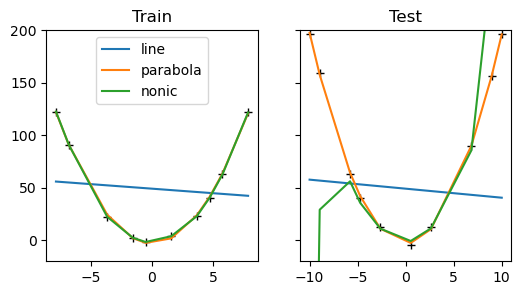

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
labels = ['line', 'parabola', 'nonic']
models = [model_one, model_two, model_three]
train = (train_ftr, train_tgt)
test = (test_ftr, test_tgt)

for ax, (ftr, tgt) in zip(axes, [train, test]):
    ax.plot(ftr, tgt, 'k+')

    for m, lbl in zip(models, labels):
        ftr = sorted(ftr)
        ax.plot(ftr, m(ftr), '-', label=lbl)
        
axes[1].set_ylim(-20, 200)
axes[0].set_title("Train")
axes[1].set_title("Test");
axes[0].legend(loc='upper center')

`model_one`, the straight line - has great difficulty because our real model follows a curved
trajectory.   
`model_two` - it follows the curve just about perfectly.  
`model_three` - seems to do wonderfully when we train. it basically overlaps with both model_two and the
real outputs. however, it has problems when we go to testing. it starts exploding out of
control near `ftr=-7`.   

we can rerun the models and gather up the
results in one table. since it is easy to add another midway model, we can throw in a
degree-6 model:

In [11]:
results = []
for complexity in [1, 2, 6, 9]:
    model = np.poly1d(np.polyfit(train_ftr, train_tgt, complexity))
    train_error = np.sqrt(mse(train_tgt, model(train_ftr)))
    test_error = np.sqrt(mse(test_tgt, model(test_ftr)))
    results.append((complexity, train_error, test_error))

columns = ["Complexity", "Train Error", "Test Error"]
results_df = pd.DataFrame.from_records(results,
columns=columns,
index="Complexity")
results_df

,Train Error,Test Error
Complexity,,
1,45.4951,86.6915
2,1.0828,1.2766
6,0.2819,6.1417
9,0.0000,317.3634


### what happened:
what happened with each of the three models with complexity 1, 2, and 9?
- model one (complexity 1—a straight line). model one was completely outclassed. the
model doesn’t have enough capacity, to capture the complexity
of a target. it is too biased towards flatness. the model is `underfitting`.
- model three (complexity 9—a wiggly 9-degree polynomial). model three certainly
had enough horsepower. we see that it does very well on the training data. in fact, it
gets to the point where it is perfect on the training data. but it completely falls apart
when it comes to testing. why? because it **memorized the noise** — the randomness
in the data. it varies too much with the data. this is a case of `overfitting`.
- model two (complexity 2—a parabola).goldilocks solution: it’s
not too hot, it’s not too cold, it’s just right. we have enough horsepower, but not so
much that we can’t control it. we do well enough on the training data and we see
that we are at the lowest testing error.


> **NOTE**:  
> if we had set up a full validation step to select
between the three machines with different complexity, we would be quite happy
with model two. model two doesn’t exactly capture the training patterns because the
training patterns include noise.


let’s graph out the results on the train and test sets:

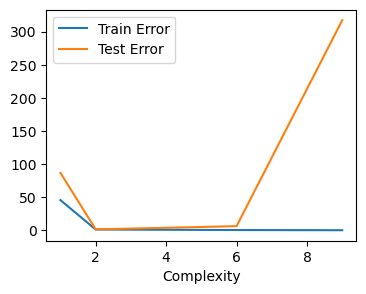

In [12]:
results_df.plot();

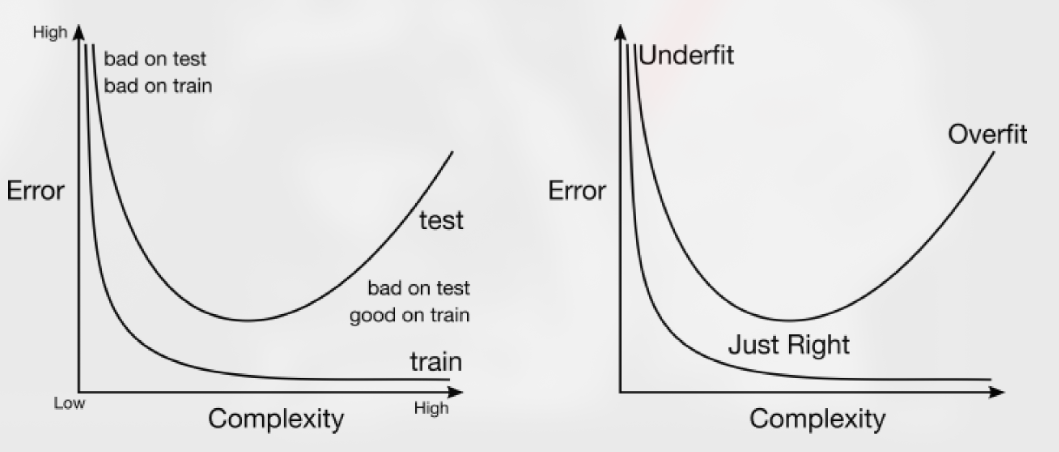

In [13]:
from IPython.display import Image
image_path = './overfitting-uderfitting.png'
Image(filename=image_path)

### wraps: overfitting and underfitting
this is a case of considering why we'd need some complexity - there is no point having it if it doesn't give us what we want and does it efficiently:

- **underfitting**: a very simple model may not be able to learn the pattern in the
training data. tt also does poorly on the testing data. 
- **overfitting**: a very complex model may learn the training data perfectly. however,
it does poorly on the testing data because it also learned irrelevant relationships in
the training data.

- **just-right**: a medium-complexity model performs well on the training and
testing data.


> INFO: we need the right tradeoff between simplicity and complexity to find a just-right
model  

### errors and costs:
error and complexity go together. eg we vary the complexity of a class of models—the degree of our
polynomials—we have different training and test performance. 

#### 1 - loss:

we’ll construct a loss function that quantifies what
happens when our model is wrong on a single example. we’ll use that to build a
training loss function that measures how well our model does on the entire training set.
more technical write-ups call this the empirical loss. rmpirical simply means “by
observation” or “as seen,” so it’s a loss based on the data we’ve seen. the **training loss** is the
sum of the losses on each example. we can write that in code as:

In [14]:
def training_loss(loss, model, training_data):
    ' total training_loss on train_data with model under loss'
    return sum(loss(model.predict(x.reshape(1, -1)), y) for x, y in training_data)

def squared_error(prediction, actual):
    ' squared error on a single example '
    return (prediction - actual)**2
# could be used like:
# my_training_loss = training_loss(squared_error, model, training_data)

In [15]:
from sklearn import neighbors 
knn = neighbors.KNeighborsRegressor(n_neighbors=3)
fit = knn.fit(diabetes.data, diabetes.target)

training_data = zip(diabetes.data, diabetes.target)
my_training_loss = training_loss(squared_error, knn, training_data)

print(my_training_loss)

[863792.3333]


let's use sklearn’s `mean_squared_error` and multiply it by the number of training
examples—to undo the mean part—we get the same answer

In [16]:
mse = metrics.mean_squared_error(diabetes.target,
knn.predict(diabetes.data))

print(mse*len(diabetes.data))

863792.3333333333


### 2 - cost:
we saw with overfitting, if we make our model more and more complex, we can
capture any pattern—even pattern that is really noise. so, we need something that works
against complexity and rewards simplicity. we do that by adding a value to the training loss
to create a total notion of cost. conceptually, $cost = loss + complexity$, but we have to fill
in some details. thi is called:
**regularization**, smoothing, penalization, or shrinkage.   

In short,
the total cost we pay to use a model on some data depends on  
(1) how well it does and
(2) how complicated it is.     

you can think of the complexity part as a baseline investment. if
we have a very high initial investment, we better not have many errors. conversely, if we
have a low initial investment, we might have some room to allow for error. 


#### generalization:
all of this is
because we want good performance on unseen data. the term for performance on novel,
unseen data is **generalization**.  
we don’t have to have a fixed idea of how to trade off error and
complexity. in technical sense, it’s just another hyperparameter(lambda, λ). we can choose a
good value of λ by performing several rounds of validation testing and taking the λ that
leads to the lowest cost

In [17]:
def complexity(model):
    return model.complexity
def cost(model, training_data, loss, _lambda):
    return training_loss(m,D) + _lambda * complexity(m)

### 3 - score
**score** or **scoring functions** — at least in sklearn’s
lexicon — are a variation on quantifying loss where bigger values are better. for our
purpose, we can consider losses and scores to be inverses: as one goes up, the other goes
down. so, we generally want a high score or a low loss...we will want to minimize a loss or loss function but we will maximize
a score or scoring function. To summarize:
- **score**: higher is better, try to maximize.
- **loss, error, and cost**: lower is better, try to minimize.

> the end of the day we ask ourselves: did we pick the best model and hyperparameters? 

### end 
> see the resampling notebook for more